In [12]:
import argparse
import torch
import numpy as np
import os
from model import BrainNetworkTransformer
from dataloader import get_dataloader
import scipy.io

def setup_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--base_path', type=str, default='/home/rendy/fMRI/DATASETS/MDD')
    parser.add_argument('--altas_name', type=str, default='AAL')
    parser.add_argument('--device', type=str, default='cuda:0')
    parser.add_argument('--n_split', type=int, default=5)
    parser.add_argument('--seed', type=int, default=2024)
    parser.add_argument('--num_epochs', type=int, default=400)
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--saved_model_dir', type=str, default='./saved_model/')
    parser.add_argument('--ext_featuresize', type=int, default=16)
    parser.add_argument('--gcn_num_epochs', type=int, default=1000)
    parser.add_argument('--numeric_features', nargs='+', default=['Age', 'Edu'])
    parser.add_argument('--text_features', nargs='+', default=['Site', 'Sex'])
    parser.add_argument('--num_features', type=int, default=16)
    parser.add_argument('--nhid', type=int, default=256)
    parser.add_argument('--dropout_ratio', type=float, default=0.3)
    parser.add_argument('--lr', type=float, default=0.01)
    return parser.parse_known_args()

def forward_hook(module, input, output):
    setattr(module, '_activations', output.detach())

def backward_hook(module, grad_in, grad_out):
    setattr(module, '_gradients', grad_out[0].detach())

def grad_cam(model, input_tensor, target_class):
    output,_ = model(input_tensor)
    activations = model.reduce_dim3._activations
    gradients = model.reduce_dim3._gradients
    # print("target_class type:", type(target_class)) 
    target_score = output[:, target_class]
    model.zero_grad()
    target_score.mean().backward()

    gradients = gradients.detach()
    activations = activations.detach()

    pooled_gradients = torch.mean(gradients, dim=[0, 2])
    for i in range(activations.shape[1]):
        activations[:, i, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=2)
    heatmap = torch.relu(heatmap)
    heatmap /= (torch.max(heatmap) + 1e-8)

    return heatmap.cpu().numpy()

def compute_heatmaps(args, task_name):
    args.task_name = task_name
    args.data_path = f"{args.base_path}/{args.task_name}/{args.task_name}_{args.altas_name}.npy"
    args.csv_path = f"{args.base_path}/{args.task_name}/{args.task_name}_{args.altas_name}.csv"
    dataloaders_list = get_dataloader(args)
    saved_model_dir = os.path.join(args.saved_model_dir, f"{args.task_name}_{args.altas_name}")
    heatmap_list_MDD = []
    heatmap_list_HC = []
    for fold, (train_dataloader, test_dataloader) in enumerate(dataloaders_list):
        model = BrainNetworkTransformer(args).to(args.device)
        forward_handle = model.reduce_dim3.register_forward_hook(forward_hook)
        backward_handle = model.reduce_dim3.register_full_backward_hook(backward_hook)
        fold_model_path = os.path.join(saved_model_dir, f'best_acc_model_{fold}.pth')
        model.load_state_dict(torch.load(fold_model_path))
        model.eval()
        for index, (time_series, node_feature, labels, indices) in enumerate(test_dataloader):
            time_series, node_feature, labels = time_series.to(args.device), node_feature.to(args.device), labels.to(args.device)
            for i in range(node_feature.shape[0]):
                single_feature = node_feature[i:i+1]
                single_label = labels[i].argmax().unsqueeze(0)
                predict, _ = model(single_feature)
                loss = torch.nn.CrossEntropyLoss(reduction='sum')(predict, single_label)
                loss.backward()
                heatmap = grad_cam(model, single_feature, single_label.item())
                if single_label.item() == 1:
                    heatmap_list_MDD.append(heatmap)
                else:
                    heatmap_list_HC.append(heatmap)
        forward_handle.remove()
        backward_handle.remove()
    return np.array(heatmap_list_MDD), np.array(heatmap_list_HC)

In [13]:
args, unknown = setup_args()
data_dict = {}
for task_name in ['848MDDvs794NC', '189Recurrentvs427NC']:
    MDD, HC = compute_heatmaps(args, task_name)
    data_dict.update({f'{task_name}_MDD': MDD, f'{task_name}_HC': HC})
scipy.io.savemat('Grad_CAM_all_data.mat', data_dict)


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

data = scipy.io.loadmat('./Grad_CAM_all_data.mat')
print(data.keys())
MDD = np.squeeze(data['848MDDvs794NC_MDD'])
HC = np.squeeze(data['848MDDvs794NC_HC'])
Recurrent_MDD = np.squeeze(data['189Recurrentvs427NC_MDD'])
Recurrent_HC = np.squeeze(data['189Recurrentvs427NC_HC'])
# 按照RSN排序
import pandas as pd
rsn_data = pd.read_csv('/home/rendy/rdyBrainNetTransformer/WithGNN/altas_label/AAL116_rsn7.csv')

data_dict = {
    'MDD': MDD,
    'HC': HC,
    'Recurrent_MDD': Recurrent_MDD,
    'Recurrent_HC': Recurrent_HC
}

dict_keys(['__header__', '__version__', '__globals__', '848MDDvs794NC_MDD', '848MDDvs794NC_HC', '189Recurrentvs427NC_MDD', '189Recurrentvs427NC_HC'])


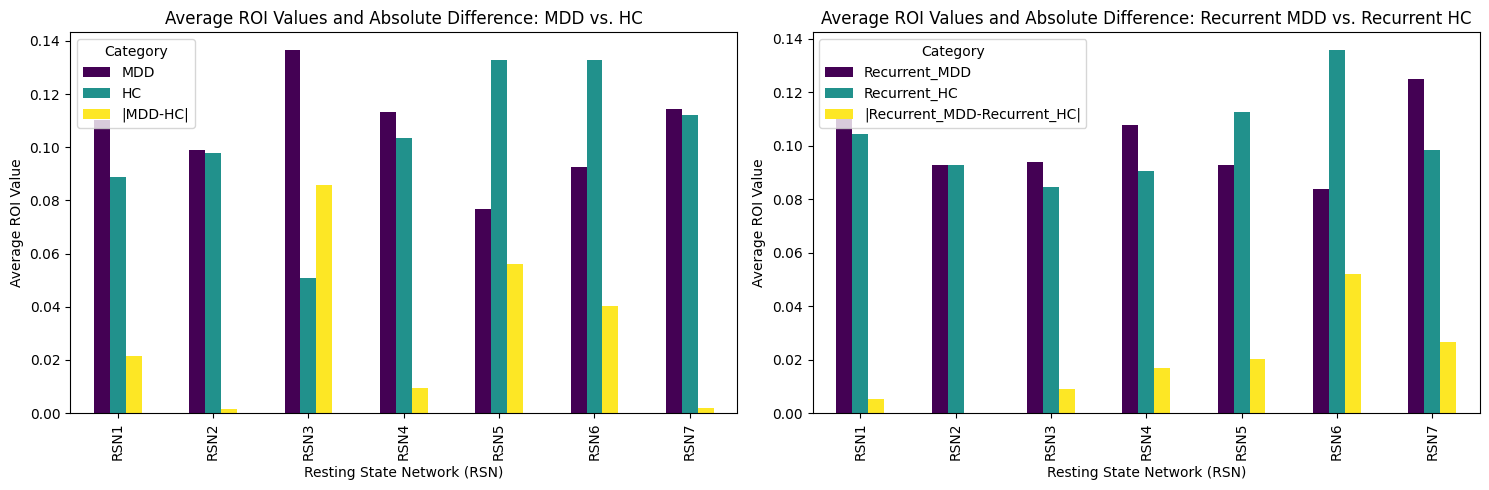

In [48]:
average_values = {}

for category, dataset in data_dict.items():
    category_averages = []
    for rsn in range(1, rsn_data['rsn'].max() + 1):
        rsn_indices = rsn_data[rsn_data['rsn'] == rsn]['index'] - 1  # zero-based index for Python
        category_averages.append(np.mean(dataset[:, rsn_indices]))
    average_values[category] = category_averages

# Convert to DataFrame for easy plotting
average_df = pd.DataFrame(average_values, index=[f'RSN{rsn}' for rsn in range(1, rsn_data['rsn'].max() + 1)])

# Calculating the absolute differences between MDD-HC and Recurrent MDD - Recurrent HC
average_df['|MDD-HC|'] = abs(average_df['MDD'] - average_df['HC'])
average_df['|Recurrent_MDD-Recurrent_HC|'] = abs(average_df['Recurrent_MDD'] - average_df['Recurrent_HC'])

# Plotting the average values and their absolute differences in two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MDD vs HC average values and their absolute differences
average_df[['MDD', 'HC', '|MDD-HC|']].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Average ROI Values and Absolute Difference: MDD vs. HC')
axes[0].set_xlabel('Resting State Network (RSN)')
axes[0].set_ylabel('Average ROI Value')
axes[0].legend(title='Category')

# Recurrent MDD vs Recurrent HC average values and their absolute differences
average_df[['Recurrent_MDD', 'Recurrent_HC', '|Recurrent_MDD-Recurrent_HC|']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Average ROI Values and Absolute Difference: Recurrent MDD vs. Recurrent HC')
axes[1].set_xlabel('Resting State Network (RSN)')
axes[1].set_ylabel('Average ROI Value')
axes[1].legend(title='Category')

plt.tight_layout()
plt.show()


In [68]:
import numpy as np
from scipy.stats import mannwhitneyu

def calculate_mann_whitney_u(data, rsn_data):
    num_rsns = rsn_data['rsn'].max()

    # Storing Mann-Whitney U test results and effect sizes
    results_initial = {}
    results_recurrent = {}

    for rsn in range(1, num_rsns + 1):
        rsn_indices = rsn_data[rsn_data['rsn'] == rsn]['index'] - 1
        
        # Initial group
        # MDD_RSN = data['MDD'][:, rsn_indices].flatten()
        # HC_RSN = data['HC'][:, rsn_indices].flatten()
        # Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].flatten()
        # Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].flatten()
        MDD_RSN = data['MDD'][:, rsn_indices].mean(axis=1)
        HC_RSN = data['HC'][:, rsn_indices].mean(axis=1)
        Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].mean(axis=1)
        Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].mean(axis=1)

        # Mann-Whitney U Test for Initial
        u_stat_initial, p_value_initial = mannwhitneyu(MDD_RSN, HC_RSN, alternative='two-sided')
        n1_initial = len(MDD_RSN)
        n2_initial = len(HC_RSN)
        r_initial = 1 - (2 * u_stat_initial) / (n1_initial * n2_initial)

        results_initial[f'RSN{rsn}'] = (u_stat_initial, p_value_initial, r_initial)

        # Mann-Whitney U Test for Recurrent
        u_stat_recurrent, p_value_recurrent = mannwhitneyu(Recurrent_MDD_RSN, Recurrent_HC_RSN, alternative='two-sided')
        n1_recurrent = len(Recurrent_MDD_RSN)
        n2_recurrent = len(Recurrent_HC_RSN)
        r_recurrent = 1 - (2 * u_stat_recurrent) / (n1_recurrent * n2_recurrent)

        results_recurrent[f'RSN{rsn}'] = (u_stat_recurrent, p_value_recurrent, r_recurrent)

    def print_results(group_name, results):
        print(f"{group_name} Group:")
        print("U-statistics:", ', '.join(f'{rsn}: {format(result[0], ".4f")}' for rsn, result in results.items()))
        print("P-values:", ', '.join(f'{rsn}: {format(result[1], ".4f")}' for rsn, result in results.items()))
        print("Rank-biserial r values:", ', '.join(f'{rsn}: {format(result[2], ".4f")}' for rsn, result in results.items()))
        print("\n")

    print_results("Initial", results_initial)
    print_results("Recurrent", results_recurrent)

# Assuming data_dict and rsn_data are properly defined
calculate_mann_whitney_u(data_dict, rsn_data)


Initial Group:
U-statistics: RSN1: 378449.0000, RSN2: 318761.0000, RSN3: 518264.0000, RSN4: 349437.0000, RSN5: 162889.0000, RSN6: 177547.5000, RSN7: 327607.0000
P-values: RSN1: 0.0000, RSN2: 0.5698, RSN3: 0.0000, RSN4: 0.0065, RSN5: 0.0000, RSN6: 0.0000, RSN7: 0.7042
Rank-biserial r values: RSN1: -0.1678, RSN2: 0.0164, RSN3: -0.5993, RSN4: -0.0783, RSN5: 0.4974, RSN6: 0.4521, RSN7: -0.0109


Recurrent Group:
U-statistics: RSN1: 41347.0000, RSN2: 41080.0000, RSN3: 44503.0000, RSN4: 47035.0000, RSN5: 32906.0000, RSN6: 18957.0000, RSN7: 53142.0000
P-values: RSN1: 0.5920, RSN2: 0.6858, RSN3: 0.0368, RSN4: 0.0009, RSN5: 0.0003, RSN6: 0.0000, RSN7: 0.0000
Rank-biserial r values: RSN1: -0.0271, RSN2: -0.0204, RSN3: -0.1055, RSN4: -0.1684, RSN5: 0.1826, RSN6: 0.5291, RSN7: -0.3201




/tmp/ipykernel_1839737/130255928.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[rsn-1, 0], x=combined_labels, y=combined_data, palette=['red', 'blue'])
/tmp/ipykernel_1839737/130255928.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[rsn-1, 1], x=combined_recurrent_labels, y=combined_recurrent_data, palette=['red', 'blue'])
/tmp/ipykernel_1839737/130255928.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[rsn-1, 0], x=combined_labels, y=combined_data, palette=['red', 'blue'])
/tmp/ipykernel_18397

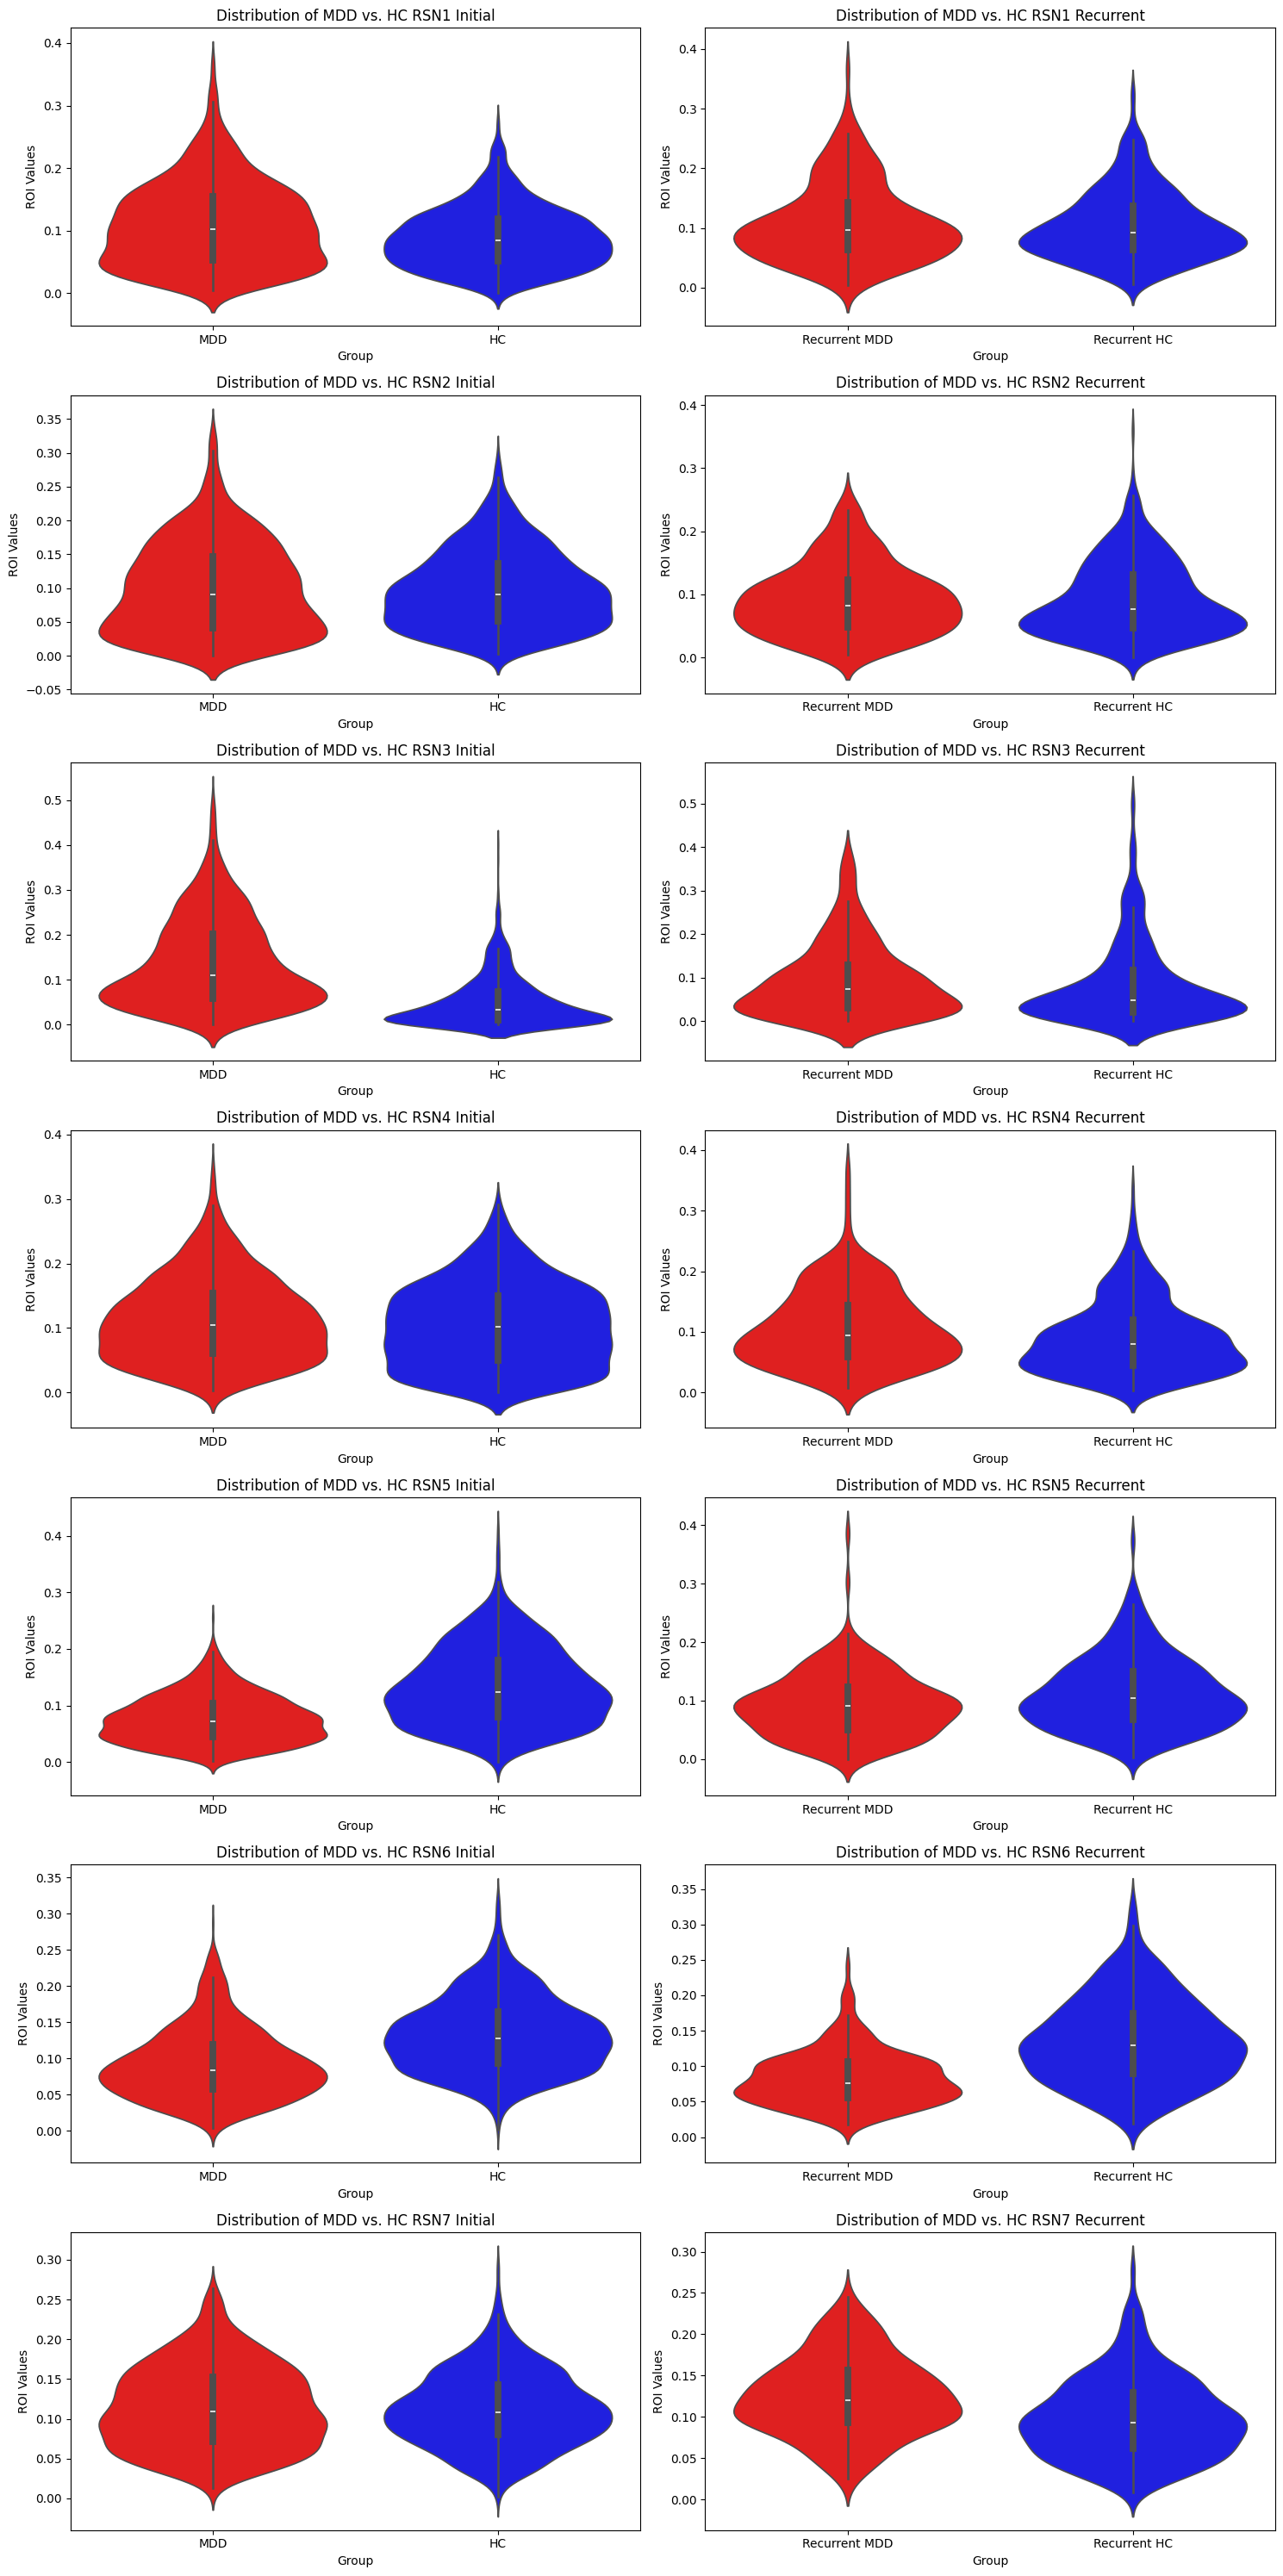

RSN1 Initial: U-statistic = 378449.0000, p-value = 0.0000, Rank-biserial r = -0.1678
RSN1 Recurrent: U-statistic = 41347.0000, p-value = 0.5920, Rank-biserial r = -0.0271
RSN2 Initial: U-statistic = 318761.0000, p-value = 0.5698, Rank-biserial r = 0.0164
RSN2 Recurrent: U-statistic = 41080.0000, p-value = 0.6858, Rank-biserial r = -0.0204
RSN3 Initial: U-statistic = 518264.0000, p-value = 0.0000, Rank-biserial r = -0.5993
RSN3 Recurrent: U-statistic = 44503.0000, p-value = 0.0368, Rank-biserial r = -0.1055
RSN4 Initial: U-statistic = 349437.0000, p-value = 0.0065, Rank-biserial r = -0.0783
RSN4 Recurrent: U-statistic = 47035.0000, p-value = 0.0009, Rank-biserial r = -0.1684
RSN5 Initial: U-statistic = 162889.0000, p-value = 0.0000, Rank-biserial r = 0.4974
RSN5 Recurrent: U-statistic = 32906.0000, p-value = 0.0003, Rank-biserial r = 0.1826
RSN6 Initial: U-statistic = 177547.5000, p-value = 0.0000, Rank-biserial r = 0.4521
RSN6 Recurrent: U-statistic = 18957.0000, p-value = 0.0000, Rank

In [66]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_rsns_and_test(data, rsn_data, title_prefix, figure_size=(15, 30)):
    num_rsns = rsn_data['rsn'].max()
    fig, axes = plt.subplots(num_rsns, 2, figsize=figure_size)  # 7 RSNs, 2 columns (initial and recurrent)

    # Storing Mann-Whitney U test results and effect sizes
    test_results = {}

    for rsn in range(1, num_rsns + 1):
        rsn_indices = rsn_data[rsn_data['rsn'] == rsn]['index'] - 1

        # Initial group
        # MDD_RSN = data['MDD'][:, rsn_indices].flatten()
        # HC_RSN = data['HC'][:, rsn_indices].flatten()
        # Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].flatten()
        # Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].flatten()

        MDD_RSN = data['MDD'][:, rsn_indices].mean(axis=1)
        HC_RSN = data['HC'][:, rsn_indices].mean(axis=1)
        Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].mean(axis=1)
        Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].mean(axis=1)
        # --------------------
        labels_MDD = ['MDD'] * len(MDD_RSN)
        labels_HC = ['HC'] * len(HC_RSN)
        combined_data = np.concatenate([MDD_RSN, HC_RSN])
        combined_labels = labels_MDD + labels_HC

        # Recurrent group
        
        labels_Recurrent_MDD = ['Recurrent MDD'] * len(Recurrent_MDD_RSN)
        labels_Recurrent_HC = ['Recurrent HC'] * len(Recurrent_HC_RSN)
        combined_recurrent_data = np.concatenate([Recurrent_MDD_RSN, Recurrent_HC_RSN])
        combined_recurrent_labels = labels_Recurrent_MDD + labels_Recurrent_HC

        # Plotting
        sns.violinplot(ax=axes[rsn-1, 0], x=combined_labels, y=combined_data, palette=['red', 'blue'])
        axes[rsn-1, 0].set_title(f'{title_prefix} RSN{rsn} Initial')
        axes[rsn-1, 0].set_xlabel('Group')
        axes[rsn-1, 0].set_ylabel('ROI Values')

        sns.violinplot(ax=axes[rsn-1, 1], x=combined_recurrent_labels, y=combined_recurrent_data, palette=['red', 'blue'])
        axes[rsn-1, 1].set_title(f'{title_prefix} RSN{rsn} Recurrent')
        axes[rsn-1, 1].set_xlabel('Group')
        axes[rsn-1, 1].set_ylabel('ROI Values')

        # Mann-Whitney U Test for Initial
        u_stat_initial, p_value_initial = mannwhitneyu(MDD_RSN, HC_RSN, alternative='two-sided')
        n1_initial = len(MDD_RSN)
        n2_initial = len(HC_RSN)
        r_initial = 1 - (2 * u_stat_initial) / (n1_initial * n2_initial)

        # Mann-Whitney U Test for Recurrent
        u_stat_recurrent, p_value_recurrent = mannwhitneyu(Recurrent_MDD_RSN, Recurrent_HC_RSN, alternative='two-sided')
        n1_recurrent = len(Recurrent_MDD_RSN)
        n2_recurrent = len(Recurrent_HC_RSN)
        r_recurrent = 1 - (2 * u_stat_recurrent) / (n1_recurrent * n2_recurrent)

        test_results[f'RSN{rsn} Initial'] = {'U-statistic': u_stat_initial, 'p-value': p_value_initial, 'r': r_initial}
        test_results[f'RSN{rsn} Recurrent'] = {'U-statistic': u_stat_recurrent, 'p-value': p_value_recurrent, 'r': r_recurrent}

    plt.tight_layout()
    plt.show()

    # Print the test results and effect sizes
    for rsn, results in test_results.items():
        u_stat = format(results["U-statistic"], ".4f")
        p_val = format(results["p-value"], ".4f")
        r_val = format(results["r"], ".4f")
        print(f'{rsn}: U-statistic = {u_stat}, p-value = {p_val}, Rank-biserial r = {r_val}')


# Assuming data_dict and rsn_data are properly defined
plot_all_rsns_and_test(data_dict, rsn_data, 'Distribution of MDD vs. HC')


In [52]:
# 这个时什么检验
import numpy as np
from scipy.stats import shapiro

def test_normality(data, rsn_data):
    num_rsns = rsn_data['rsn'].max()
    normality_results = {}

    for rsn in range(1, num_rsns + 1):
        rsn_indices = rsn_data[rsn_data['rsn'] == rsn]['index'] - 1

        # Initial group
        MDD_RSN = data['MDD'][:, rsn_indices].flatten()
        HC_RSN = data['HC'][:, rsn_indices].flatten()

        # Recurrent group
        Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].flatten()
        Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].flatten()

        # Perform Shapiro-Wilk test and store results
        normality_results[f'RSN{rsn} Initial MDD'] = shapiro(MDD_RSN)
        normality_results[f'RSN{rsn} Initial HC'] = shapiro(HC_RSN)
        normality_results[f'RSN{rsn} Recurrent MDD'] = shapiro(Recurrent_MDD_RSN)
        normality_results[f'RSN{rsn} Recurrent HC'] = shapiro(Recurrent_HC_RSN)

    return normality_results

# Assuming data_dict and rsn_data are properly defined
results = test_normality(data_dict, rsn_data)
for key, value in results.items():
    print(f'{key}: Statistic={value[0]}, p-value={value[1]}')


RSN1 Initial MDD: Statistic=0.6253498792648315, p-value=0.0
RSN1 Initial HC: Statistic=0.6080890893936157, p-value=0.0
RSN1 Recurrent MDD: Statistic=0.632197916507721, p-value=0.0
RSN1 Recurrent HC: Statistic=0.6387597322463989, p-value=0.0
RSN2 Initial MDD: Statistic=0.6020447015762329, p-value=0.0
RSN2 Initial HC: Statistic=0.644990861415863, p-value=0.0
RSN2 Recurrent MDD: Statistic=0.5965404510498047, p-value=0.0
RSN2 Recurrent HC: Statistic=0.5987386107444763, p-value=0.0
RSN3 Initial MDD: Statistic=0.6993066072463989, p-value=0.0
RSN3 Initial HC: Statistic=0.4515568017959595, p-value=0.0
RSN3 Recurrent MDD: Statistic=0.5953251123428345, p-value=2.802596928649634e-45
RSN3 Recurrent HC: Statistic=0.5603609085083008, p-value=0.0
RSN4 Initial MDD: Statistic=0.647313117980957, p-value=0.0
RSN4 Initial HC: Statistic=0.614108681678772, p-value=0.0
RSN4 Recurrent MDD: Statistic=0.598630964756012, p-value=0.0
RSN4 Recurrent HC: Statistic=0.5861021280288696, p-value=0.0
RSN5 Initial MDD: S

/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.

In [55]:
import numpy as np
from scipy.stats import shapiro, ttest_ind

def test_normality_and_t_test(data, rsn_data):
    num_rsns = rsn_data['rsn'].max()
    results = {}

    for rsn in range(1, num_rsns + 1):
        rsn_indices = rsn_data[rsn_data['rsn'] == rsn]['index'] - 1

        # Initial group
        MDD_RSN = data['MDD'][:, rsn_indices].flatten()
        HC_RSN = data['HC'][:, rsn_indices].flatten()

        # Recurrent group
        Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].flatten()
        Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].flatten()

        # Perform Shapiro-Wilk test
        results[f'RSN{rsn} Initial MDD'] = {
            'Shapiro-Wilk': shapiro(MDD_RSN)
        }
        results[f'RSN{rsn} Initial HC'] = {
            'Shapiro-Wilk': shapiro(HC_RSN)
        }
        results[f'RSN{rsn} Recurrent MDD'] = {
            'Shapiro-Wilk': shapiro(Recurrent_MDD_RSN)
        }
        results[f'RSN{rsn} Recurrent HC'] = {
            'Shapiro-Wilk': shapiro(Recurrent_HC_RSN)
        }

        # Perform Welch's t-tests
        # Initial vs Recurrent MDD
        stat, p = ttest_ind(MDD_RSN, Recurrent_MDD_RSN, equal_var=False)
        results[f'RSN{rsn} Welch t-test MDD vs. Recurrent MDD'] = {'Statistic': stat, 'p-value': p}

        # Initial HC vs Recurrent HC
        stat, p = ttest_ind(HC_RSN, Recurrent_HC_RSN, equal_var=False)
        results[f'RSN{rsn} Welch t-test HC vs. Recurrent HC'] = {'Statistic': stat, 'p-value': p}

    return results

# Assuming data_dict and rsn_data are properly defined
results = test_normality_and_t_test(data_dict, rsn_data)
for key, value in results.items():
    if isinstance(value, dict):
        print(f'{key}:')
        for test, result in value.items():
            print(f'  {test}: Statistic={result[0]}, p-value={result[1]}')


RSN1 Initial MDD:
  Shapiro-Wilk: Statistic=0.6253498792648315, p-value=0.0
RSN1 Initial HC:
  Shapiro-Wilk: Statistic=0.6080890893936157, p-value=0.0
RSN1 Recurrent MDD:
  Shapiro-Wilk: Statistic=0.632197916507721, p-value=0.0
RSN1 Recurrent HC:
  Shapiro-Wilk: Statistic=0.6387597322463989, p-value=0.0
RSN1 Welch t-test MDD vs. Recurrent MDD:


/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.

IndexError: invalid index to scalar variable.

In [49]:
from scipy.stats import ttest_ind

# Function to perform t-tests across all RSNs
def perform_t_tests(data, rsn_data):
    num_rsns = rsn_data['rsn'].max()
    results = {}

    for rsn in range(1, num_rsns + 1):
        # Get indices for the current RSN
        rsn_indices = rsn_data[rsn_data['rsn'] == rsn]['index'] - 1

        # Extract data for this RSN for each group
        MDD_RSN = data['MDD'][:, rsn_indices].flatten()
        HC_RSN = data['HC'][:, rsn_indices].flatten()
        Recurrent_MDD_RSN = data['Recurrent_MDD'][:, rsn_indices].flatten()
        Recurrent_HC_RSN = data['Recurrent_HC'][:, rsn_indices].flatten()

        # Perform t-tests
        t_stat_initial, p_val_initial = ttest_ind(MDD_RSN, HC_RSN, equal_var=False)
        t_stat_recurrent, p_val_recurrent = ttest_ind(Recurrent_MDD_RSN, Recurrent_HC_RSN, equal_var=False)

        # Store results
        results[f'RSN{rsn} Initial MDD vs HC'] = (t_stat_initial, p_val_initial)
        results[f'RSN{rsn} Recurrent MDD vs HC'] = (t_stat_recurrent, p_val_recurrent)

    return results

# Call the function and get t-test results
t_test_results = perform_t_tests(data_dict, rsn_data)
t_test_results
# t-Statistic	p-Value

{'RSN1 Initial MDD vs HC': (8.873560334631348, 7.60687529783946e-19),
 'RSN1 Recurrent MDD vs HC': (1.1864696529312382, 0.23549570505439335),
 'RSN2 Initial MDD vs HC': (0.5740986482586296, 0.5659067795348829),
 'RSN2 Recurrent MDD vs HC': (0.04142292782349619, 0.9669603807423048),
 'RSN3 Initial MDD vs HC': (24.510696048305768, 3.01814049484081e-128),
 'RSN3 Recurrent MDD vs HC': (1.4563787448342944, 0.14543662287475195),
 'RSN4 Initial MDD vs HC': (4.002050667400981, 6.297177209568401e-05),
 'RSN4 Recurrent MDD vs HC': (3.9909483918696487, 6.673104547245404e-05),
 'RSN5 Initial MDD vs HC': (-20.360244333079354, 4.94684456324235e-91),
 'RSN5 Recurrent MDD vs HC': (-4.3475188589260005, 1.4066209861998746e-05),
 'RSN6 Initial MDD vs HC': (-21.059175925173328, 6.072169096909435e-98),
 'RSN6 Recurrent MDD vs HC': (-16.90152179547435, 2.0957494918636806e-63),
 'RSN7 Initial MDD vs HC': (1.0562961676172538, 0.290839023865309),
 'RSN7 Recurrent MDD vs HC': (7.3567814902175, 2.067197268092465

In [1]:
# 计算MDD与HC
import argparse
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from model import BrainNetworkTransformer
from dataloader import get_dataloader
parser = argparse.ArgumentParser()
import numpy as np
import os

#---Grad CAM---
def forward_hook(module, input, output):
    setattr(module, '_activations', output.detach())

def backward_hook(module, grad_in, grad_out):
    setattr(module, '_gradients', grad_out[0].detach())

def grad_cam(model, input_tensor, target_class):
    output,_ = model(input_tensor)
    activations = model.reduce_dim3._activations
    gradients = model.reduce_dim3._gradients
    # print("target_class type:", type(target_class)) 
    target_score = output[:, target_class]
    model.zero_grad()
    target_score.mean().backward()

    gradients = gradients.detach()
    activations = activations.detach()

    pooled_gradients = torch.mean(gradients, dim=[0, 2])
    for i in range(activations.shape[1]):
        activations[:, i, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=2)
    heatmap = torch.relu(heatmap)
    heatmap /= (torch.max(heatmap) + 1e-8)

    return heatmap.cpu().numpy()


/home/rendy/.conda/envs/geometric/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
parser.add_argument('--task_name', type=str, default='848MDDvs794NC', help='Name of the task') # 232FEDNvs394NC  189Recurrentvs427NC   119FEDNvs72Recurrent 848MDDvs794NC
parser.add_argument('--altas_name', type=str, default='AAL', help='Name of the altas') # CC200 Dosenbach HO AAL
base_path = '/home/rendy/fMRI/DATASETS/MDD'
args, unknown = parser.parse_known_args()
data_path = f"{base_path}/{args.task_name}/{args.task_name}_{args.altas_name}.npy"
csv_path = f"{base_path}/{args.task_name}/{args.task_name}_{args.altas_name}.csv"
#---不同模板---
parser.add_argument('--data_path', type=str, default=data_path, help='Path to the data file')
parser.add_argument('--csv_path', type=str, default=csv_path, help='Path to the CSV file')

# ------experiment config------ #
parser.add_argument('--n_split', type=int, default=5, help='n-fold cross validation')
parser.add_argument('--seed', type=int, default=2024, help='random seed')
parser.add_argument('--device', type=str, default='cuda:0', help='specify cuda devices')

# ------Transformer config------ #
parser.add_argument('--num_epochs', type=int, default=400, help='num_epochs')
parser.add_argument('--batch_size', type=int, default=32, help='batch size')
parser.add_argument('--saved_model_dir', type=str, default='./saved_model/', help='root of saved_model')


# ------ext feature------ #
parser.add_argument('--ext_featuresize', type=int, default=16, help='exc_featuresize')
# ------GNN config------ #

parser.add_argument('--gcn_num_epochs', type=int, default=1000, help='num_epochs')
parser.add_argument('--numeric_features', type=str, default=['Age', 'Edu'], help='numeric features')
parser.add_argument('--text_features', type=str, default=['Site', 'Sex'], help='text features ')
parser.add_argument('--num_features', type=int, default=16, help='num_features')# 和ext_featuresize一样，一会改一下
parser.add_argument('--nhid', type=int, default=256, help='hidden size ')
parser.add_argument('--dropout_ratio', type=float, default=0.3, help='dropout ratio')
parser.add_argument('--lr', type=float, default=0.01, help='learning rate')

args, unknown = parser.parse_known_args()



# 计算MDD与HC的平均热图
dataloaders_list = get_dataloader(args)
saved_model_dir = os.path.join(args.saved_model_dir, f"{args.task_name}_{args.altas_name}")

heatmap_list_MDD = []
heatmap_list_HC = []
heatmap_list_all = []

for fold, (train_dataloader, test_dataloader) in enumerate(dataloaders_list):
    model = BrainNetworkTransformer(args).to(args.device)
    forward_handle = model.reduce_dim3.register_forward_hook(forward_hook)
    backward_handle = model.reduce_dim3.register_full_backward_hook(backward_hook)
    fold_model_path = os.path.join(saved_model_dir, f'best_acc_model_{fold}.pth')
    model.load_state_dict(torch.load(fold_model_path))
    model.eval()

    for index, (time_series, node_feature, labels, indices) in enumerate(test_dataloader):
        time_series, node_feature, labels = time_series.to(args.device), node_feature.to(args.device), labels.to(args.device)
        for i in range(node_feature.shape[0]):
            single_feature = node_feature[i:i+1]  # 提取单个样本的特征
            single_label = labels[i].argmax().unsqueeze(0)   # 这是独热编码标签，形状类似于 [0, 1]

            # 转换独热编码为类别索引
            # target_class = single_label.argmax().item()  # 提取索引
            predict, _ = model(single_feature)
            # 使用类别索引计算损失
            loss = torch.nn.CrossEntropyLoss(reduction='sum')(predict, single_label)
            loss.backward()
            # 传递类别索引的整数值给 grad_cam
            heatmap = grad_cam(model, single_feature, single_label.item())

            heatmap_list_all.append(heatmap)

            if single_label.item() == 1:  # 假设标签1为患病
                heatmap_list_MDD.append(heatmap)
            else:
                heatmap_list_HC.append(heatmap)

    forward_handle.remove()
    backward_handle.remove()

# 计算每个组的平均热图
heatmap_avg_MDD = np.mean(heatmap_list_MDD, axis=0)
heatmap_avg_HC = np.mean(heatmap_list_HC, axis=0)
heatmap_avg_all = np.mean(heatmap_list_all, axis=0)
heatmap_differences = np.abs(heatmap_avg_MDD - heatmap_avg_HC)

heatmap_list_MDD = np.array(heatmap_list_MDD)
heatmap_list_HC = np.array(heatmap_list_HC)


In [11]:
args.task_name = '189Recurrentvs427NC'
data_path = f"{base_path}/{args.task_name}/{args.task_name}_{args.altas_name}.npy"
csv_path = f"{base_path}/{args.task_name}/{args.task_name}_{args.altas_name}.csv"

# 计算MDD与HC的平均热图
dataloaders_list = get_dataloader(args)
saved_model_dir = os.path.join(args.saved_model_dir, f"{args.task_name}_{args.altas_name}")

heatmap_list_MDD = []
heatmap_list_HC = []
heatmap_list_all = []

for fold, (train_dataloader, test_dataloader) in enumerate(dataloaders_list):
    model = BrainNetworkTransformer(args).to(args.device)
    forward_handle = model.reduce_dim3.register_forward_hook(forward_hook)
    backward_handle = model.reduce_dim3.register_full_backward_hook(backward_hook)
    fold_model_path = os.path.join(saved_model_dir, f'best_acc_model_{fold}.pth')
    model.load_state_dict(torch.load(fold_model_path))
    model.eval()

    for index, (time_series, node_feature, labels, indices) in enumerate(test_dataloader):
        time_series, node_feature, labels = time_series.to(args.device), node_feature.to(args.device), labels.to(args.device)
        for i in range(node_feature.shape[0]):
            single_feature = node_feature[i:i+1]  # 提取单个样本的特征
            single_label = labels[i].argmax().unsqueeze(0)   # 这是独热编码标签，形状类似于 [0, 1]

            # 转换独热编码为类别索引
            # target_class = single_label.argmax().item()  # 提取索引
            predict, _ = model(single_feature)
            # 使用类别索引计算损失
            loss = torch.nn.CrossEntropyLoss(reduction='sum')(predict, single_label)
            loss.backward()
            # 传递类别索引的整数值给 grad_cam
            heatmap = grad_cam(model, single_feature, single_label.item())

            heatmap_list_all.append(heatmap)

            if single_label.item() == 1:  # 假设标签1为患病
                heatmap_list_MDD.append(heatmap)
            else:
                heatmap_list_HC.append(heatmap)

    forward_handle.remove()
    backward_handle.remove()

# 计算每个组的平均热图
heatmap_avg_MDD = np.mean(heatmap_list_MDD, axis=0)
heatmap_avg_HC = np.mean(heatmap_list_HC, axis=0)
heatmap_avg_all = np.mean(heatmap_list_all, axis=0)
heatmap_differences = np.abs(heatmap_avg_MDD - heatmap_avg_HC)

heatmap_list_Recurrent_MDD = np.array(heatmap_list_MDD)
heatmap_list_Recurrent_HC = np.array(heatmap_list_HC)

In [ ]:

import scipy.io 
data_dict = {
    'MDD': heatmap_list_MDD,
    'HC': heatmap_list_HC,
    'Recurrent_MDD': heatmap_list_Recurrent_MDD,
    'Recurrent_HC': heatmap_list_Recurrent_HC
}

# 保存数据到单个MAT文件
scipy.io.savemat('Grad_CAM_all_data.mat', data_dict)

In [3]:
# 打印出前十的latex表格代码------------------------------------------------------------------------------------------
import pandas as pd
def get_top_values(tensor):
    squeezed_tensor = tensor.squeeze()
    top_values, top_indices = torch.topk(squeezed_tensor, 10)
    return top_indices.numpy(), top_values.numpy()

indices_mdd, values_mdd = get_top_values(torch.from_numpy(heatmap_avg_MDD))
indices_hc, values_hc = get_top_values(torch.from_numpy(heatmap_avg_HC))
indices_all, values_all = get_top_values(torch.from_numpy(heatmap_avg_all))

top_diff_values, top_diff_indices = torch.topk(torch.from_numpy(heatmap_differences.squeeze()), 10)

df_label = pd.read_csv('/home/rendy/rdyBrainNetTransformer/WithGNN/altas_label/AAL116_label.csv')
def create_dataframe(indices, values,df_label):
    # 根据indices从label文件中拿出名称
    labels = df_label.set_index('index').loc[indices+1]['label']
    df = pd.DataFrame({
        'Region ID': indices,
        'Region Name': labels,  # 空白的region name
        'Value': values
    })
    return df

df_mdd = create_dataframe(indices_mdd, values_mdd,df_label)
df_hc = create_dataframe(indices_hc, values_hc,df_label)
df_all = create_dataframe(indices_all, values_all,df_label)
df_diff = create_dataframe(top_diff_indices, top_diff_values,df_label)

latex_mdd = df_mdd.to_latex(index=False, header=True)
latex_hc = df_hc.to_latex(index=False, header=True)
latex_all = df_all.to_latex(index=False, header=True)
latex_diff = df_diff.to_latex(index=False, header=True)
# print(args.task_name)
# print("MDD Contribution Top 10 LaTeX Code:")
# print(latex_mdd)
# print("\nHC Contribution Top 10 LaTeX Code:")
# print(latex_hc)
# print("\nAll Samples Contribution Top 10 LaTeX Code:")
# print(latex_all)
# print("Top 10 Differences between MDD and HC:")
# print(latex_diff)

Shape of heatmap_avg_MDD: (1, 116)


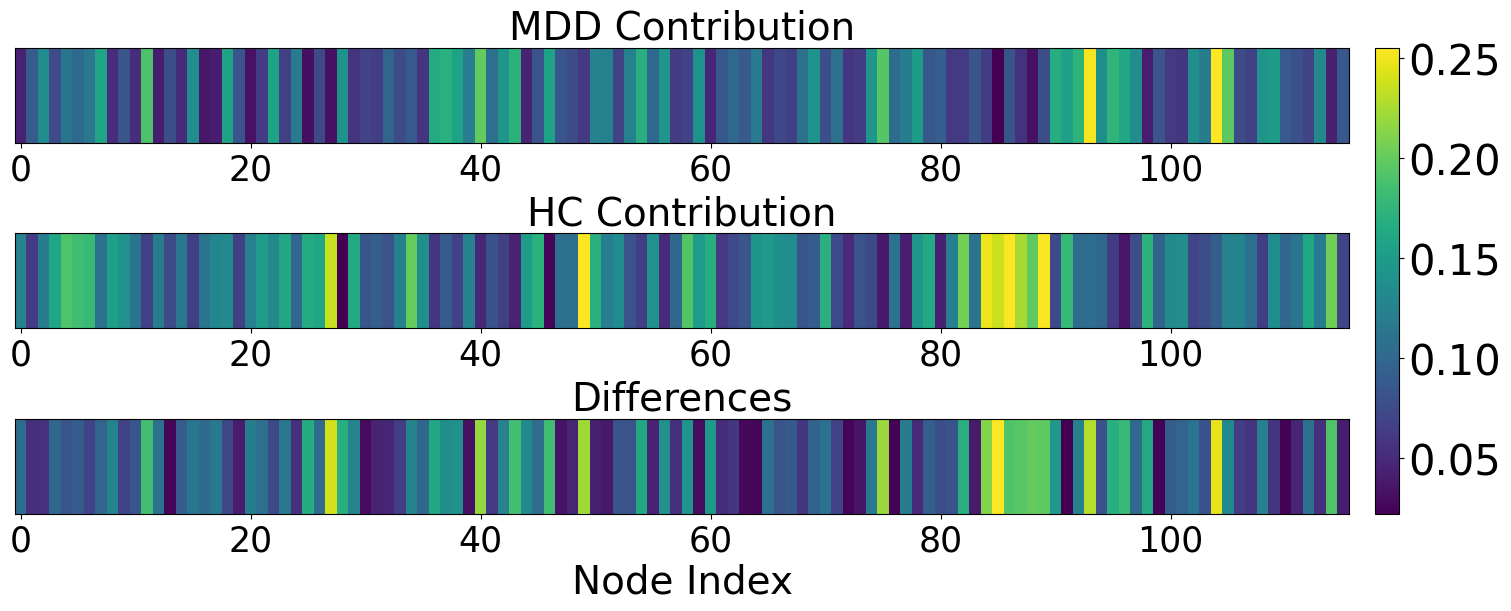

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(15, 6), constrained_layout=True)  # 增加了图的高度
cmap = 'viridis'

# Example data shapes (assuming they are 2D already)
print("Shape of heatmap_avg_MDD:", heatmap_avg_MDD.shape)

# Ensure conversion to numpy if they are tensors and use imshow directly on 2D data
img1 = axs[0].imshow(heatmap_avg_MDD, aspect='auto', cmap=cmap)
axs[0].set_title("MDD Contribution", fontsize=28)  # 增加了标题字体大小
axs[0].set_yticks([])  # Hides y-axis ticks

img2 = axs[1].imshow(heatmap_avg_HC, aspect='auto', cmap=cmap)
axs[1].set_title("HC Contribution", fontsize=28)
axs[1].set_yticks([])

# img3 = axs[2].imshow(heatmap_avg_all, aspect='auto', cmap=cmap)
# axs[2].set_title("All Samples Contribution", fontsize=28)
# axs[2].set_yticks([])

img4 = axs[2].imshow(heatmap_differences, aspect='auto', cmap=cmap)
axs[2].set_title("Differences", fontsize=28)
axs[2].set_yticks([])

# 设置色标和其字体大小
cbar = fig.colorbar(img1, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=30)  # 调整色标刻度字体大小

for ax in axs:
    ax.tick_params(axis='x', labelsize=25) 
# 设置 x 轴标签并调整字体大小
axs[2].set_xlabel("Node Index", fontsize=28)

plt.show()


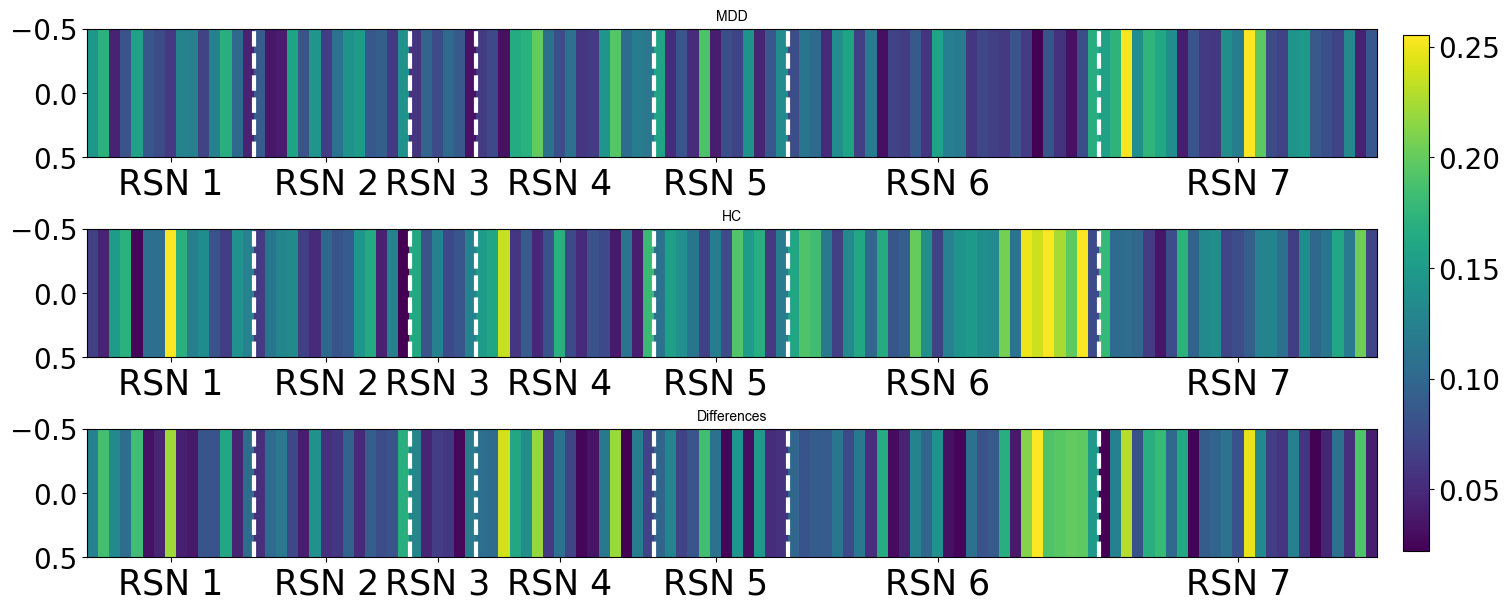

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# 设置字体路径
font_path = '/home/rendy/rdyBrainNetTransformer/WithGNN/arial.ttf'

# 使用指定的字体
font = FontProperties(fname=font_path)

# 导入数据
rsn_data = pd.read_csv('/home/rendy/rdyBrainNetTransformer/WithGNN/altas_label/AAL116_rsn7.csv')
grouped_rsn = rsn_data.groupby('rsn')['index'].apply(list)

# 重新排序数据以聚集相同RSN的节点
sorted_indices = sorted(rsn_data['index'] - 1, key=lambda x: rsn_data.iloc[x]['rsn'])  # 1-based index转为0-based
rsn_labels_sorted = [rsn_data.iloc[x]['rsn'] for x in sorted_indices]

# 重新排列热图数据
heatmap_avg_MDD_sorted = heatmap_avg_MDD[:, sorted_indices]
heatmap_avg_HC_sorted = heatmap_avg_HC[:, sorted_indices]
heatmap_avg_all_sorted = heatmap_avg_all[:, sorted_indices]
heatmap_diff = np.abs(heatmap_avg_MDD_sorted - heatmap_avg_HC_sorted)

# 保存数据
np.savetxt('heatmap_recurrent_MDD.txt', heatmap_avg_MDD_sorted, fmt='%f')
# 保存 heatmap_avg_HC
np.savetxt('heatmap_recurrent_HC.txt', heatmap_avg_HC_sorted, fmt='%f')
# 保存 heatmap_diff
np.savetxt('heatmap_recurrent_diff.txt', heatmap_diff, fmt='%f')

# 设置绘图
fig, axs = plt.subplots(3, 1, figsize=(15, 6), constrained_layout=True)
cmap = 'viridis'  # 选择适合的颜色映射

# 绘制每个热图
axs[0].imshow(heatmap_avg_MDD_sorted, aspect='auto', cmap=cmap)
axs[0].set_title("MDD", fontsize=30,fontproperties=font)  # 调整标题字体大小

axs[1].imshow(heatmap_avg_HC_sorted, aspect='auto', cmap=cmap)
axs[1].set_title("HC", fontsize=30,fontproperties=font)  # 调整标题字体大小

im2 = axs[2].imshow(heatmap_diff, aspect='auto', cmap=cmap)
axs[2].set_title("Differences", fontsize=30, fontproperties=font)

# 添加色标并调整色标的字体大小
cbar = fig.colorbar(axs[0].images[0], ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=20)  # 调整色标刻度字体大小

# 计算RSN中点并标注
rsn_midpoints = []
rsn_labels = []
current_rsn = rsn_labels_sorted[0]
start_index = 0
rsn_ends = []  # 收集RSN边界索引
for i, rsn in enumerate(rsn_labels_sorted + [None], 1):
    if rsn != current_rsn:
        end_index = i - 1
        midpoint = (start_index + end_index) // 2
        rsn_midpoints.append(midpoint)
        rsn_labels.append(f"RSN {current_rsn}")
        rsn_ends.append(end_index)  # 收集边界
        start_index = i
        current_rsn = rsn

# 在每个RSN之间画分界线
for end in rsn_ends[:-1]:  # 最后一个分界线不需要绘制
    for ax in axs:
        ax.axvline(x=end + 0.5, color='white', linestyle='--', linewidth=3)

# 设置x轴，并调整刻度标签的字体大小
for ax in axs:
    ax.set_xticks(rsn_midpoints)
    ax.set_xticklabels(rsn_labels, rotation=0, ha='center', fontsize=25)  # 调整x轴刻度标签字体大小

# 调整y轴刻度标签的字体大小（如果有）
for ax in axs:
    ax.tick_params(axis='y', labelsize=20)

plt.show()


In [9]:
rsn_ends
rsn_labels
rsn_midpoints
rsn_ends

[14, 28, 34, 50, 62, 90, 116]

In [18]:
grouped_rsn = rsn_data.groupby('rsn')['index'].apply(list)
rsn_averages_diff = {}
heatmap_diff_tensor = torch.tensor(heatmap_diff, dtype=torch.float)
for rsn, indices in grouped_rsn.items():
    # 将索引转换为0-based，然后转换为tensor
    indices_tensor = torch.tensor([i - 1 for i in indices], dtype=torch.long)  # 1-based to 0-based index
    rsn_averages_diff[f'RSN {rsn}'] = torch.mean(heatmap_diff_tensor[:, indices_tensor], dim=1)
print("Average differences for each RSN:")
for rsn, avg_diff in rsn_averages_diff.items():
    print(f"{rsn}: {avg_diff.numpy()}")

Average differences for each RSN:
RSN 1: [0.07661409]
RSN 2: [0.07557433]
RSN 3: [0.09179082]
RSN 4: [0.0579669]
RSN 5: [0.12440065]
RSN 6: [0.0900206]
RSN 7: [0.09237087]


In [107]:
# 方差齐性检验
# heatmap_list_MDD 是(样本数, 1, 脑区数)
from scipy.stats import levene, shapiro

# 假设 heatmap_list_MDD 和 heatmap_list_HC 已经是加载好的 NumPy 数组
# 并且它们的形状是 (样本数, 1, 脑区数)，我们需要将它们调整为 (样本数, 脑区数)
heatmap_list_MDD = np.squeeze(heatmap_list_MDD)
heatmap_list_HC = np.squeeze(heatmap_list_HC)
num_brain_areas = heatmap_list_MDD.shape[1]

# 初始化字典来存储每个脑区的检验结果
levene_results = {}
shapiro_results_MDD = {}
shapiro_results_HC = {}

num_areas_with_equal_variances = 0
num_areas_normal_MDD = 0
num_areas_normal_HC = 0

# 遍历每一个脑区进行Levene's Test和Shapiro-Wilk Test
for i in range(num_brain_areas):
    data_MDD = heatmap_list_MDD[:, i]
    data_HC = heatmap_list_HC[:, i]

    # 方差齐性检验
    stat_levene, p_value_levene = levene(data_MDD, data_HC)
    levene_results[f'Brain Area {i+1}'] = {'Statistic': stat_levene, 'P-value': p_value_levene}
    if p_value_levene > 0.05:
        num_areas_with_equal_variances += 1

    # 正态性检验 (MDD)
    stat_shapiro_MDD, p_value_shapiro_MDD = shapiro(data_MDD)
    shapiro_results_MDD[f'Brain Area {i+1}'] = {'Statistic': stat_shapiro_MDD, 'P-value': p_value_shapiro_MDD}
    if p_value_shapiro_MDD > 0.05:
        num_areas_normal_MDD += 1

    # 正态性检验 (HC)
    stat_shapiro_HC, p_value_shapiro_HC = shapiro(data_HC)
    shapiro_results_HC[f'Brain Area {i+1}'] = {'Statistic': stat_shapiro_HC, 'P-value': p_value_shapiro_HC}
    if p_value_shapiro_HC > 0.05:
        num_areas_normal_HC += 1

# 输出结果
print(f"Number of brain areas with equal variances: {num_areas_with_equal_variances}/{num_brain_areas}")
print(f"Number of MDD brain areas with normal distribution: {num_areas_normal_MDD}/{num_brain_areas}")
print(f"Number of HC brain areas with normal distribution: {num_areas_normal_HC}/{num_brain_areas}")



Number of brain areas with equal variances: 30/116
Number of MDD brain areas with normal distribution: 0/116
Number of HC brain areas with normal distribution: 0/116


In [110]:
# 显著脑区的数量
from scipy.stats import mannwhitneyu

# 假设 heatmap_list_MDD 和 heatmap_list_HC 已经是加载好的 NumPy 数组
# 并且它们的形状是 (样本数, 1, 脑区数)，我们需要将它们调整为 (样本数, 脑区数)
heatmap_list_MDD = np.squeeze(heatmap_list_MDD)
heatmap_list_HC = np.squeeze(heatmap_list_HC)
num_brain_areas = heatmap_list_MDD.shape[1]

# 存储每个脑区的检验结果
mann_whitney_results = {}

# 用于计数统计显著的脑区数量
num_significant_areas = 0

# 遍历每一个脑区进行Mann-Whitney U Test
for i in range(num_brain_areas):
    data_MDD = heatmap_list_MDD[:, i]
    data_HC = heatmap_list_HC[:, i]
    stat, p_value = mannwhitneyu(data_MDD, data_HC, alternative='two-sided')
    mann_whitney_results[f'Brain Area {i+1}'] = {'Statistic': stat, 'P-value': p_value}
    if p_value < 0.05:
        num_significant_areas += 1

# 输出显著脑区的数量
print(f"Number of significant brain areas: {num_significant_areas}/{num_brain_areas}")

from statsmodels.stats.multitest import multipletests

# 假设 p_values 是我们从Mann-Whitney U测试中得到的p值列表
p_values = [mann_whitney_results[area]['P-value'] for area in mann_whitney_results]

# 应用Bonferroni校正
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# 计算校正后的显著脑区数量
num_significant_areas_corrected = sum(reject)

print(f"Number of significant brain areas after Bonferroni correction: {num_significant_areas_corrected}/{num_brain_areas}")



Number of significant brain areas: 88/116
Number of significant brain areas after Bonferroni correction: 59/116


In [3]:
def forward_hook(module, input, output):
    setattr(module, '_activations', output.detach())

def backward_hook(module, grad_in, grad_out):
    setattr(module, '_gradients', grad_out[0].detach())

def grad_cam(model, input_tensor, target_class):
    output,_ = model(input_tensor)
    activations = model.reduce_dim3._activations
    gradients = model.reduce_dim3._gradients
    # print("target_class type:", type(target_class)) 
    target_score = output[:, target_class]
    model.zero_grad()
    target_score.mean().backward()

    gradients = gradients.detach()
    activations = activations.detach()

    pooled_gradients = torch.mean(gradients, dim=[0, 2])
    for i in range(activations.shape[1]):
        activations[:, i, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=2)
    heatmap = torch.relu(heatmap)
    heatmap /= (torch.max(heatmap) + 1e-8)

    return heatmap.cpu().numpy()

class HeatmapGroup:
    def __init__(self, node_size):
        self.sum = torch.zeros(node_size)
        self.count = 0
    
    def update(self, heatmap):
        if heatmap is not None:
            self.sum += heatmap
            self.count += 1
        else:
            print("Warning: Received None heatmap")
    
    def average(self):
        return self.sum / self.count if self.count > 0 else torch.zeros_like(self.sum)

def compute_difference(heatmap1, heatmap2):
    return torch.abs(heatmap1 - heatmap2)


dataloaders_list = get_dataloader(args)
saved_model_dir = os.path.join(args.saved_model_dir, f"{args.task_name}_{args.altas_name}")
Phenotypic = pd.read_csv('/home/rendy/fMRI/DATASETS/MDD/848MDDvs794NC/848MDDvs794NC_AAL.csv', index_col='Index')

groups = {
    'MDD_male': HeatmapGroup(args.node_sz),
    'MDD_female': HeatmapGroup(args.node_sz),
    'HC_male': HeatmapGroup(args.node_sz),
    'HC_female': HeatmapGroup(args.node_sz),
    'MDD_young': HeatmapGroup(args.node_sz),
    'MDD_middle_aged': HeatmapGroup(args.node_sz),
    'MDD_senior': HeatmapGroup(args.node_sz),
    'HC_young': HeatmapGroup(args.node_sz),
    'HC_middle_aged': HeatmapGroup(args.node_sz),
    'HC_senior': HeatmapGroup(args.node_sz)
}

for fold, (train_dataloader, test_dataloader) in enumerate(dataloaders_list):
    model = BrainNetworkTransformer(args).to(args.device)
    forward_handle = model.reduce_dim3.register_forward_hook(forward_hook)
    backward_handle = model.reduce_dim3.register_full_backward_hook(backward_hook)
    fold_model_path = os.path.join(saved_model_dir, f'best_acc_model_{fold}.pth')
    model.load_state_dict(torch.load(fold_model_path))
    model.eval()
    
    for index, (time_series, node_feature, labels, indices) in enumerate(test_dataloader):
        
        time_series, node_feature, labels = time_series.to(args.device), node_feature.to(args.device), labels.to(args.device)
        indices_np = indices.numpy().astype(int)  # 将张量转换为 Numpy 数组
        sample_ages = Phenotypic.loc[indices_np, 'Age'].values
        sample_sexes = Phenotypic.loc[indices_np, 'Sex'].values

        for i in range(node_feature.shape[0]):
            single_feature = node_feature[i:i+1]  # 提取单个样本的特征
            single_label = labels[i].argmax().unsqueeze(0)   # 这是独热编码标签，形状类似于 [0, 1]
            
            predict, _ = model(single_feature)

            # 使用类别索引计算损失
            loss = torch.nn.CrossEntropyLoss(reduction='sum')(predict, single_label)
            loss.backward()
            # 传递类别索引的整数值给 grad_cam
            heatmap = grad_cam(model, single_feature, single_label.item())
            if np.isnan(heatmap).any():
                print(f"NaN detected in heatmap output for sample {indices_np[i]}")
                continue 

            age_group = 'young' if 18 <= sample_ages[i] <= 30 else 'middle_aged' if 31 <= sample_ages[i] <= 60 else 'senior'
            sex = 'male' if sample_sexes[i] == 0 else 'female'
            label = 'MDD' if single_label.item() == 1 else 'HC'
            
            groups[f'{label}_{sex}'].update(heatmap)
            groups[f'{label}_{age_group}'].update(heatmap)

    forward_handle.remove()
    backward_handle.remove()

averages = {key: group.average() for key, group in groups.items()}
differences = {
    'MDD_vs_HC_male': compute_difference(averages['MDD_male'], averages['HC_male']),
    'MDD_vs_HC_female': compute_difference(averages['MDD_female'], averages['HC_female']),
    'MDD_vs_HC_young': compute_difference(averages['MDD_young'], averages['HC_young']),
    'MDD_vs_HC_middle_aged': compute_difference(averages['MDD_middle_aged'], averages['HC_middle_aged']),
    'MDD_vs_HC_senior': compute_difference(averages['MDD_senior'], averages['HC_senior'])
}

NameError: name 'pd' is not defined

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设你已经有了differences字典中的这些数据
heatmap_diff_male = differences['MDD_vs_HC_male']
heatmap_diff_female = differences['MDD_vs_HC_female']
heatmap_diff_young = differences['MDD_vs_HC_young']
heatmap_diff_middle_aged = differences['MDD_vs_HC_middle_aged']
heatmap_diff_senior = differences['MDD_vs_HC_senior']

print("Shape of heatmap_diff_male:", heatmap_diff_male.shape)
print("Min/Max of heatmap_diff_male:", heatmap_diff_male.min(), heatmap_diff_male.max())


# 读取RSN数据并排序
rsn_data = pd.read_csv('/home/rendy/rdyBrainNetTransformer/WithGNN/altas_label/AAL116_rsn7.csv')
sorted_indices = sorted(rsn_data['index'] - 1, key=lambda x: rsn_data.iloc[x]['rsn'])
rsn_labels_sorted = [rsn_data.iloc[x]['rsn'] for x in sorted_indices]

# 根据排序重排热图数据
heatmap_diff_male_sorted = heatmap_diff_male[:, sorted_indices]
heatmap_diff_female_sorted = heatmap_diff_female[:, sorted_indices]
heatmap_diff_young_sorted = heatmap_diff_young[:, sorted_indices]
heatmap_diff_middle_aged_sorted = heatmap_diff_middle_aged[:, sorted_indices]
heatmap_diff_senior_sorted = heatmap_diff_senior[:, sorted_indices]




Shape of heatmap_diff_male: torch.Size([1, 116])
Min/Max of heatmap_diff_male: tensor(0.0008) tensor(0.2738)


In [ ]:
np.savetxt('heatmap_male_rsn.txt', heatmap_diff_male_sorted, fmt='%f')
np.savetxt('heatmap_female_rsn.txt', heatmap_diff_female_sorted, fmt='%f')
np.savetxt('heatmap_young_rsn.txt', heatmap_diff_young_sorted, fmt='%f')
np.savetxt('heatmap_middle_aged_rsn.txt', heatmap_diff_middle_aged_sorted, fmt='%f')
np.savetxt('heatmap_senior_rsn.txt', heatmap_diff_senior_sorted, fmt='%f')

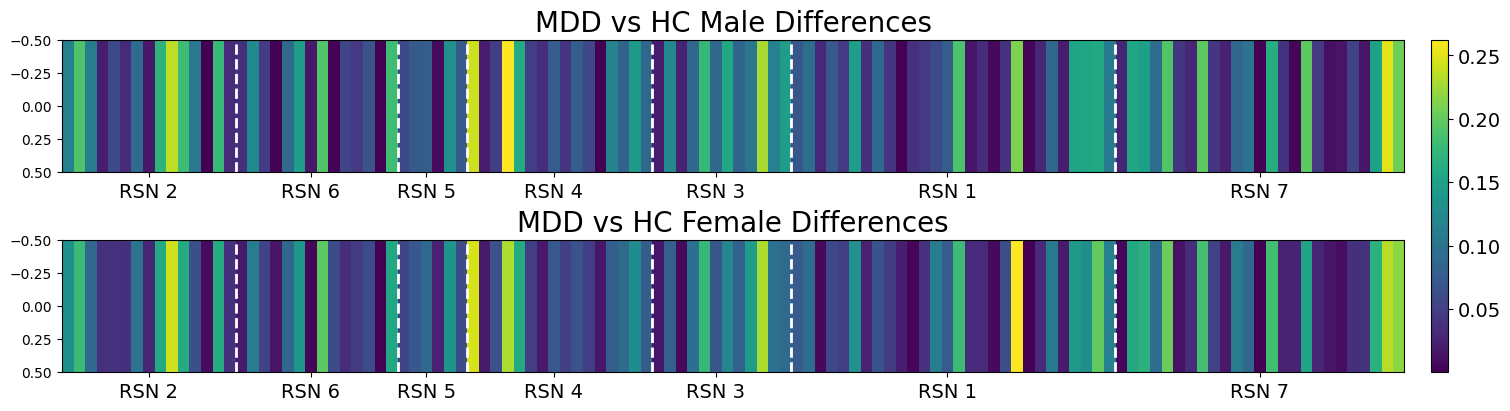

In [191]:
fig, axs = plt.subplots(2, 1, figsize=(15, 4), constrained_layout=True)
cmap = 'viridis'  # 颜色映射

# 性别差异图
axs[0].imshow(heatmap_diff_male_sorted, aspect='auto', cmap=cmap)
axs[0].set_title("MDD vs HC Male Differences", fontsize=20)
axs[1].imshow(heatmap_diff_female_sorted, aspect='auto', cmap=cmap)
axs[1].set_title("MDD vs HC Female Differences", fontsize=20)

# 添加色标
cbar = fig.colorbar(axs[0].images[0], ax=axs.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=14)  # 调整色标刻度字体大小

# 在每个RSN之间画分界线
for end in rsn_ends[:-1]:  # 最后一个分界线不需要绘制
    for ax in axs:
        ax.axvline(x=end + 0.5, color='white', linestyle='--', linewidth=2)

# 设置x轴刻度标签
for ax in axs:
    ax.set_xticks(rsn_midpoints)
    ax.set_xticklabels([f"RSN {label}" for label in rsn_data['rsn'].unique()], rotation=0, ha='center', fontsize=14)

plt.show()


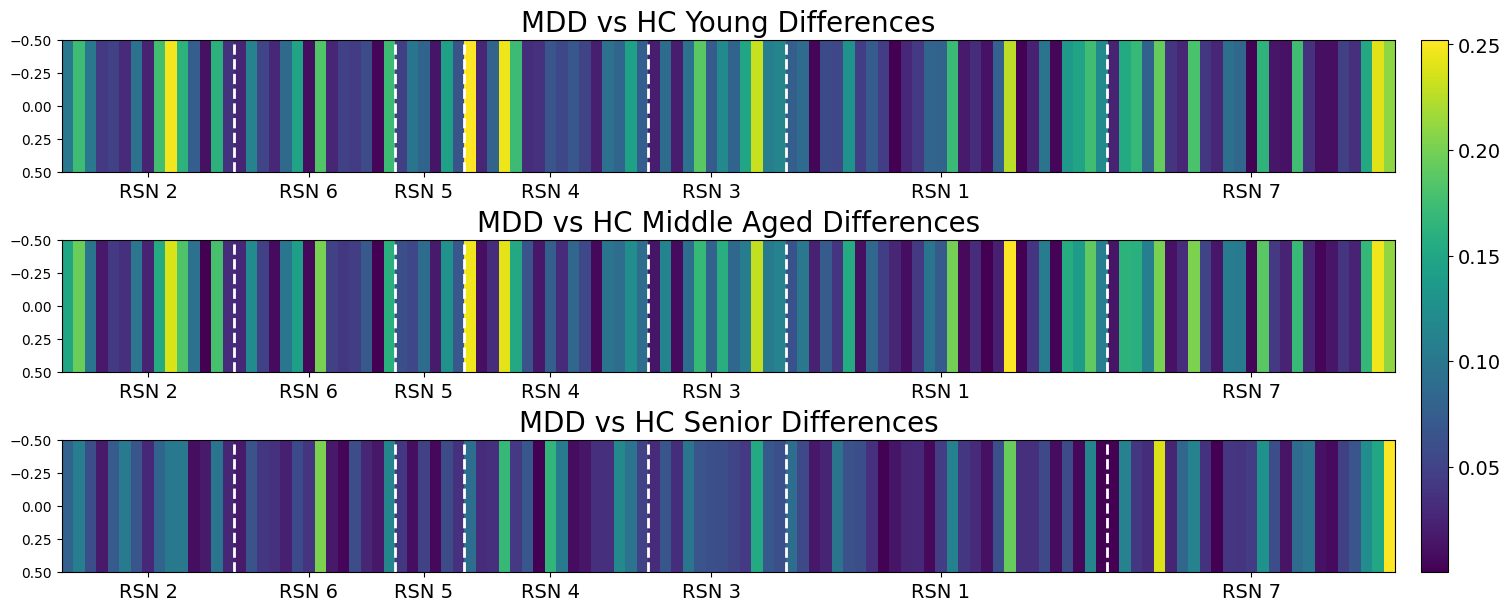

In [192]:
fig, axs = plt.subplots(3, 1, figsize=(15, 6), constrained_layout=True)
cmap = 'viridis'  # 颜色映射

# 年龄差异图
axs[0].imshow(heatmap_diff_young_sorted, aspect='auto', cmap=cmap)
axs[0].set_title("MDD vs HC Young Differences", fontsize=20)
axs[1].imshow(heatmap_diff_middle_aged_sorted, aspect='auto', cmap=cmap)
axs[1].set_title("MDD vs HC Middle Aged Differences", fontsize=20)
axs[2].imshow(heatmap_diff_senior_sorted, aspect='auto', cmap=cmap)
axs[2].set_title("MDD vs HC Senior Differences", fontsize=20)

# 添加色标
cbar = fig.colorbar(axs[0].images[0], ax=axs.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=14)  # 调整色标刻度字体大小

# 在每个RSN之间画分界线
for end in rsn_ends[:-1]:  # 最后一个分界线不需要绘制
    for ax in axs:
        ax.axvline(x=end + 0.5, color='white', linestyle='--', linewidth=2)

# 设置x轴刻度标签
for ax in axs:
    ax.set_xticks(rsn_midpoints)
    ax.set_xticklabels([f"RSN {label}" for label in rsn_data['rsn'].unique()], rotation=0, ha='center', fontsize=14)

plt.show()
